# Integrating a patient cohort with scDEF

Five patients, one shared biology, five different batches. The task is the one every cohort study
faces: pull out the cell states that are **shared across patients** without mistaking a batch effect
for biology, or erasing real patient-specific signal while correcting for one.

This runs the real **[scDEF](https://github.com/cbg-ethz/scDEF)** (Ferreira et al.) — a hierarchical
Bayesian factor model — **in this notebook's own kernel** (`Python (iscc-scdef)`), so its own
plotting works and the model object is right here to inspect.

It loads a pre-generated cohort; see
[The analysis dataset and its ground truth](analysis_ground_truth.ipynb) for how it was made and what
is held back:

| file | what it is | who sees it |
|---|---|---|
| `counts.csv.gz` | cells × genes, five patients pooled | the tool |
| `obs.csv` | each cell's patient and batch | the tool (batch only) |
| `truth_loading.csv.gz` | the shared program dictionary iscc planted | **scoring only** |
| `truth_activity.csv.gz` | each cell's true program activities | **scoring only** |

**What makes this measurable.** Every patient draws from the *same* program dictionary while its
tumour evolves privately — its own clones, its own copy-number landscape. So a shared program is
genuinely shared, and we know exactly which genes it spans.

In [1]:
import os, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scdef
from scdef import plotting as sdp

DATA = os.path.join("..", "analysis_data", "cohort")
assert os.path.isdir(DATA), (
    f"dataset not found at {DATA}\n"
    "  generate it first:  python validation/make_analysis_data.py --only cohort")

X   = pd.read_csv(os.path.join(DATA, "counts.csv.gz"), index_col=0)
obs = pd.read_csv(os.path.join(DATA, "obs.csv"), index_col=0)
meta = json.load(open(os.path.join(DATA, "meta.json")))

adata = ad.AnnData(X.values.astype("float32"))
adata.obs_names = list(X.index); adata.var_names = list(X.columns)
adata.obs["patient"] = pd.Categorical(obs.loc[X.index, "patient"])
adata.obs["batch"]   = pd.Categorical(obs.loc[X.index, "batch"])
adata.layers["counts"] = adata.X.copy()

print(f"cohort: {meta['n_patients']} patients, {meta['n_cells']:,} cells, "
      f"{meta['n_genes']} genes, {meta['n_programs']} planted programs")
print("cells per patient:", adata.obs['patient'].value_counts().to_dict())
print(f"scDEF {scdef.__version__} running in-process (kernel: Python (iscc-scdef))")

/Users/pedroferreira/miniconda3/envs/iscc-scdef/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cohort: 5 patients, 1,500 cells, 400 genes, 6 planted programs
cells per patient: {'P0': 300, 'P1': 300, 'P2': 300, 'P3': 300, 'P4': 300}
scDEF 0.6.1 running in-process (kernel: Python (iscc-scdef))


## Fit

scDEF is given the batch label and does its own correction — the honest way to test it, rather than
pre-correcting the counts by hand and handing it something already cleaned.

In [2]:
# n_factors above the 6 planted programs, so scDEF has room to invent a spurious one if the data
# invites it — giving it exactly as many factors as there are programs would hide that.
sd = scdef.scDEF(adata, counts_layer="counts", n_factors=meta["n_programs"] + 2,
                 batch_key="batch", seed=1)
sd.fit(n_epoch=300)
print("fitted. posterior-mean matrices available:", sorted(sd.pmeans)[:8])

INFO:scDEF:Found 5 values for `batch` in data: ['batch0' 'batch1' 'batch2' 'batch3' 'batch4']


INFO:scDEF:Each epoch contains 6 batches of size 256


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:09<?, ?it/s, Loss=2.18e+9]

  0%|          | 1/300 [00:09<46:53,  9.41s/it, Loss=2.18e+9]

...

INFO:scDEF:Updated adata.uns with layer 4 signatures: `L4_signatures`.


INFO:scDEF:Updated adata.obs with layer 5: `L5` and `L5_score` for all factors in layer 5


INFO:scDEF:Updated adata.obsm with layer 5: `X_L5`


INFO:scDEF:Updated adata.uns with layer 5 signatures: `L5_signatures`.


fitted. posterior-mean matrices available: ['L0W', 'L0z', 'L1W', 'L1z', 'L2W', 'L2z', 'L3W', 'L3z']


## scDEF's own figure: the factor hierarchy

scDEF does not infer a flat set of factors — it infers a **hierarchy**, broad factors at the top
splitting into finer ones below. That graph is its signature output and the thing it offers over a
flat factor model, so it is what a user would look at first.

`fit()` builds the graph, but the drawing is done from the model's *confident signatures*, which are
a separate post-fit step (`scd.tl.set_confident_signatures`) — calling `make_graph` without it raises
a `KeyError` telling you exactly that.

layer sizes (finest -> coarsest): [8, 5, 3, 2, 1, 1]


INFO:scDEF:Updated scDEF graph


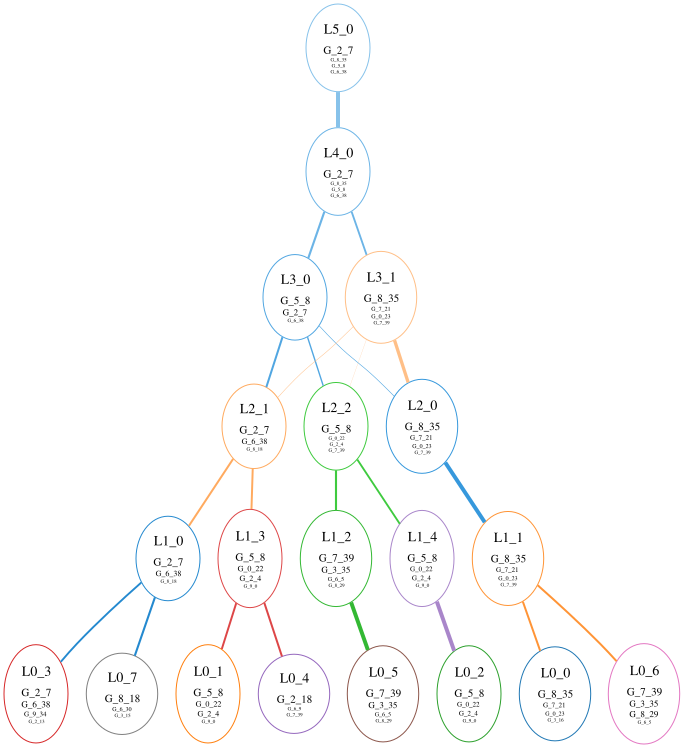

In [3]:
import scdef as scd

print("layer sizes (finest -> coarsest):", sd.layer_sizes)
scd.tl.set_confident_signatures(sd)
sdp.make_graph(sd, show_all=False)

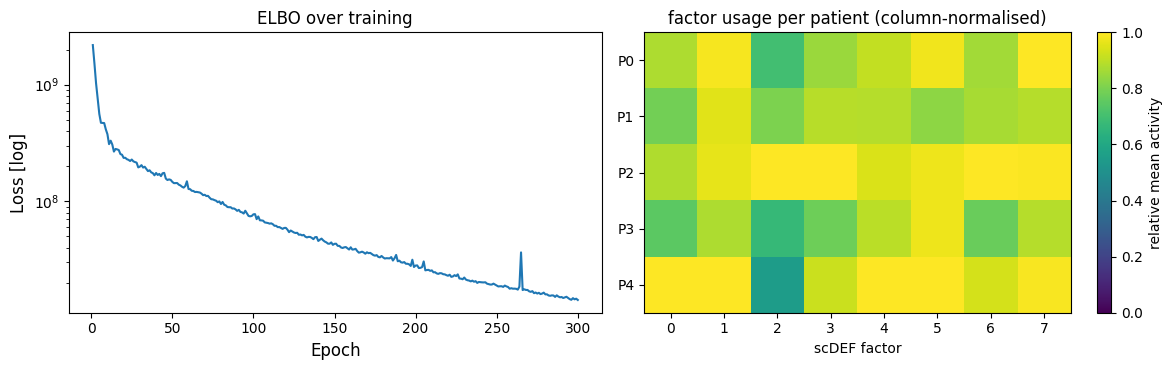

In [4]:
# The cohort view: L0z holds the per-cell activities of the finest layer, so averaging within a
# patient says which factors that patient uses.
Z = np.asarray(sd.pmeans["L0z"])                      # cells x factors
patients = adata.obs["patient"].astype(str).values

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sdp.loss(sd, ax=axes[0], show=False)
axes[0].set_title("ELBO over training")

# Mean activity of each factor within each patient. A SHARED program is used by every patient (a
# full column); a factor confined to one row is patient-specific — or that patient's batch.
usage = np.vstack([Z[patients == p].mean(0) for p in sorted(set(patients))])
usage = usage / np.clip(usage.max(0, keepdims=True), 1e-9, None)
im = axes[1].imshow(usage, aspect="auto", cmap="viridis", vmin=0, vmax=1)
axes[1].set_yticks(range(len(set(patients)))); axes[1].set_yticklabels(sorted(set(patients)))
axes[1].set_xlabel("scDEF factor"); axes[1].set_title("factor usage per patient (column-normalised)")
fig.colorbar(im, ax=axes[1], label="relative mean activity")
fig.tight_layout()

## Scoring against the planted dictionary

Now the truth. Each planted program is Hungarian-matched to its best inferred factor by cosine over
the gene loadings, which is how `validate_programs` scores the same model.

In [5]:
from scipy.optimize import linear_sum_assignment

true_loading = pd.read_csv(os.path.join(DATA, "truth_loading.csv.gz"), index_col=0)
true_loading = true_loading[adata.var_names].values          # align genes to the fitted matrix

# L0W is the FINEST layer's gene loadings (factors x genes) — the matrix comparable to the planted
# dictionary. L0z holds the per-cell activities, and L1W the hierarchy above it.
W = np.asarray(sd.pmeans["L0W"])

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return 0.0 if na == 0 or nb == 0 else float(a @ b / (na * nb))

K = true_loading.shape[0]
C = np.array([[cosine(true_loading[i], W[j]) for j in range(W.shape[0])] for i in range(K)])
rows, cols = linear_sum_assignment(-C)
matched = C[rows, cols]

print("shared-program recovery (cosine to the planted dictionary):")
for i, j in zip(rows, cols):
    print(f"  program{i}  ->  factor {j:<3} cosine {C[i, j]:.2f}")
print(f"\n  mean matched cosine: {matched.mean():.2f}")

shared-program recovery (cosine to the planted dictionary):
  program0  ->  factor 3   cosine 0.82
  program1  ->  factor 5   cosine 0.37
  program2  ->  factor 7   cosine 0.08
  program3  ->  factor 0   cosine 0.71
  program4  ->  factor 4   cosine 0.22
  program5  ->  factor 1   cosine 0.79

  mean matched cosine: 0.50


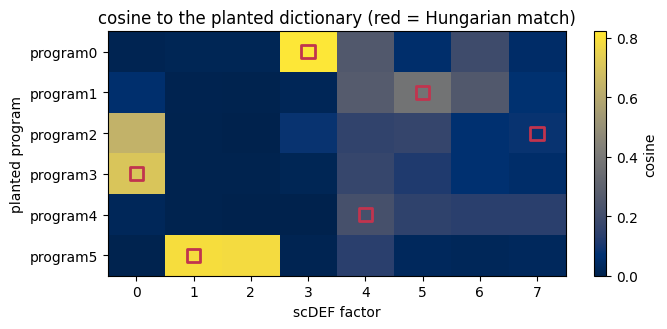

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
im = ax.imshow(C, aspect="auto", cmap="cividis", vmin=0, vmax=max(0.5, C.max()))
ax.scatter(cols, rows, marker="s", s=90, facecolors="none", edgecolors="#c1344e", linewidths=2)
ax.set_xlabel("scDEF factor"); ax.set_ylabel("planted program")
ax.set_yticks(range(K)); ax.set_yticklabels([f"program{i}" for i in range(K)])
ax.set_title("cosine to the planted dictionary (red = Hungarian match)")
fig.colorbar(im, ax=ax, label="cosine")
fig.tight_layout()

## What to take from it

A cohort integration is only useful if the shared biology survives it. Two things worth checking on
your own data, both visible above: whether patients **mix** in the factor space (they should, for a
shared program) and whether the recovered factors still look like the biology you expect (they
should not collapse into one factor per patient, which is batch masquerading as signal).

`iscc` makes the second checkable, because the dictionary every patient drew from is recorded.